## Modeling for predicting critical outcome at ED disposition

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve, get_lstm_data_gen
from dataset_path import output_path

df_train = pd.read_csv('mv_train_DISPOSITION.csv')
df_test = pd.read_csv('mv_test_DISPOSITION.csv')
df_val = pd.read_csv("mv_val_DISPOSITION.csv")
confidence_interval = 95
random_seed=0

2026-04-07 12:38:51.687902: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 12:38:51.879999: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-07 12:38:52.735909: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 12:38:52.735989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 12:38:52.924875: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 

df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,17625,13109623,NaN,34225339,2140-04-07 14:05:00,2140-04-07 14:24:00,63,F,2137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2140,66,False,False,False,0 days 00:19:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,0.32,NaN,NaN,36.055556,69.000000,16.000000,98.000000,116.000000,77.000000,6.000000,...,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,36.777778,58.0,18.0,98.0,138.0,83.0,5.0,5.0,8.0,90.000000,4,4,7,0,0,1,train,female with pmhx of copd presents with worseni...,['files/p1310/p13109623/s42270583/42270583']
1,2551,10455855,28782492.0,39040844,2173-05-23 15:30:00,2173-05-24 14:15:00,83,F,2168,NaN,2173-05-23 23:27:00,2173-05-24 14:15:00,NaN,BLACK/AFRICAN AMERICAN,2173-05-23 15:30:00,2173-05-24 14:15:00,Medicare,2173,88,False,False,False,0 days 22:45:00,NaN,NaN,False,True,False,1,3,6,2173-10-09 16:37:00,138 days 02:22:00,False,1,3,6,0,0,0,22.75,NaN,138.1,36.712811,88.000000,20.000000,99.000000,136.000000,72.000000,8.000000,...,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,36.833333,67.0,16.0,100.0,158.0,66.0,0.0,6.0,21.0,93.333333,13,9,6,0,0,1,train,hx dm cad dddr pacer htn pvd ckd and other med...,['files/p1045/p10455855/s42219625/42219625']
2,206075,16957065,20359481.0,31366838,2141-05-15 12:48:00,2141-05-15 14:33:48,45,M,2141,NaN,2141-05-15 14:33:00,2141-05-17 11:28:00,NaN,BLACK/AFRICAN AMERICAN,2141-05-15 12:48:00,2141-05-16 16:06:00,Other,2141,45,False,False,False,0 days 01:45:48,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,1.76,NaN,NaN,36.712811,85.085489,17.554838,98.374259,134.906695,77.480026,4.167576,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.666667,76.0,16.0,99.0,116.0,88.0,0.0,12.0,1.0,96.622249,0,0,2,0,0,1,train,exam chest single ap upright portable view cli...,['files/p1695/p16957065/s42159886/42159886']
3,286106,11250014,28672115.0,33227506,2153-12-15 19:16:00,2153-12-16 02:45:00,66,M,2153,NaN,2153-12-16 01:03:00,2153-12-22 15:15:00,NaN,WHITE,2153-12-15 19:16:00,2153-12-16 02:45:00,Medicare,2153,66,False,False,False,0 days 07:29:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,7.48,NaN,NaN,37.388889,90.000000,18.000000,95.000000,143.000000,78.000000,8.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.666667,73.0,17.0,95.0,161.0,71.0,3.0,1.0,0.0,99.666667,2,4,5,1,0,1,train,examination pelvis w judet views 3v indication...,['files/p1125/p11250014/s40838501/40838501']
4,175768,11575157,23296236.0,34870767,2209-06-01 15:54:00,2209-06-02 03:26:00,63,F,2201,NaN,2209-06-02 01:09:00,2209-06-05 17:00:00,NaN,BLACK/AFRICAN AMERICAN,2209-06-01 15:54:00,2209-06-02 03:26:00,Medicare,2209,71,False,False,False,0 days 11:32:00,NaN,NaN,False,True,False,0,0,2,2209-09-08 13:03:00,98 days 09:37:00,False,0

### 1. task-specific filter: No specific filtering needed

In [4]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 151886 , testing size = 18986


### 2. Variable Selection

In [5]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache", 
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", "cci_Pulmonary", 
            "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", "cci_DM2", 
            "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", "cci_Cancer2", 
            "cci_HIV",
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",  
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss", 
            "eci_Anemia", "eci_Alcohol", "eci_Drugs", "eci_Psychoses", "eci_Depression",
            
            "ed_temperature_last", "ed_heartrate_last", "ed_resprate_last", 
            "ed_o2sat_last", "ed_sbp_last", "ed_dbp_last", "ed_los", "n_med", "n_medrecon"]

outcome = "outcome_critical"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [7]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_los,n_med,n_medrecon
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,object,float64,float64


In [8]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [9]:
X_train['ed_los'] = pd.to_timedelta(X_train['ed_los']).dt.seconds / 60
X_test['ed_los'] = pd.to_timedelta(X_test['ed_los']).dt.seconds / 60
X_val['ed_los'] = pd.to_timedelta(X_val['ed_los']).dt.seconds / 60

In [10]:
print('class ratio')
print('positiave : negative =', y_train.sum()/(~y_train).sum(), ': 1')

class ratio
positiave : negative = 0.11752371002038069 : 1


### 3.  Modeling script

In [11]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 4.540330410003662 seconds
AUC: 0.812401914724019
AUPRC: 0.4216115366160618
Sensitivity: 0.7318913480885312
Specificity: 0.7450876573714555
Score thresold: 0.10097248549004015
2.5 97.5


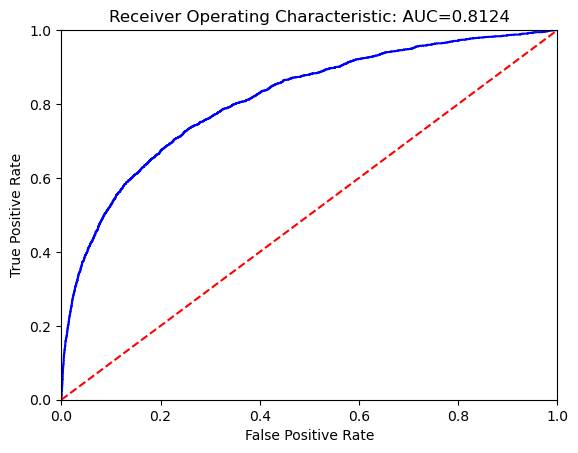

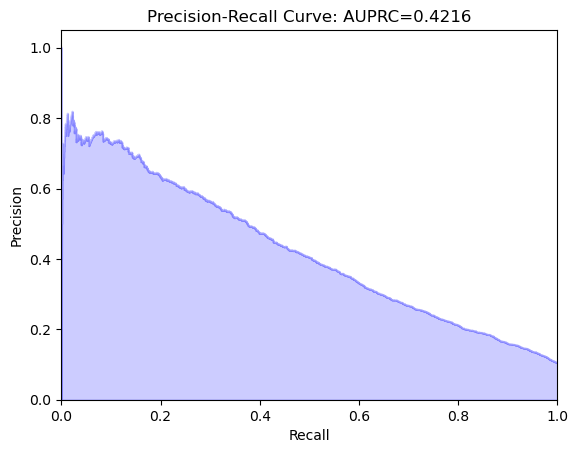

In [12]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task4_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 24.95828342437744 seconds
AUC: 0.9046980287419303
AUPRC: 0.6170424565986645
Sensitivity: 0.8329979879275654
Specificity: 0.8032709730556536
Score thresold: 0.13
2.5 97.5


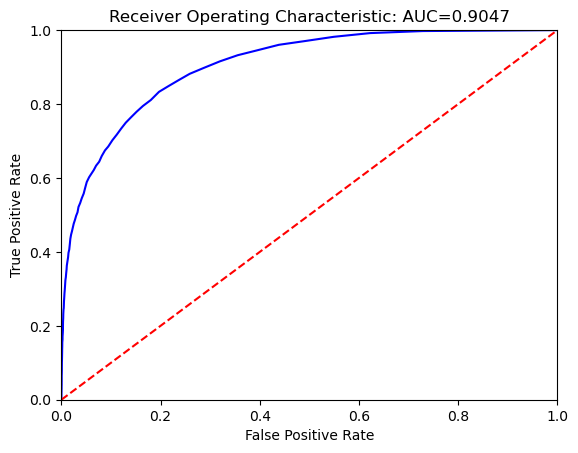

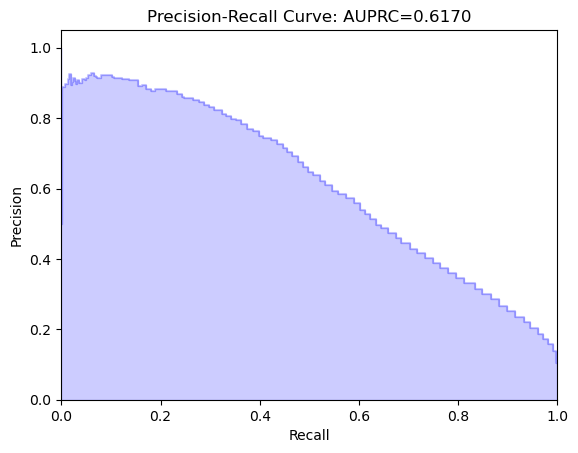

[0.05120994 0.00946205 0.00507026 0.00841452 0.01502309 0.00533985
 0.00846668 0.01436095 0.00336498 0.00591704 0.00975836 0.04086923
 0.08583902 0.00537404 0.00387125 0.00224514 0.00103448 0.00129323
 0.00193578 0.00191547 0.00365529 0.00200091 0.00205507 0.00437934
 0.00502004 0.0044159  0.00427828 0.00233071 0.00562212 0.0021675
 0.00234171 0.00374415 0.00570543 0.004138   0.00218896 0.00463034
 0.00455716 0.00234464 0.00324765 0.00092652 0.00598399 0.00412861
 0.00381903 0.00460553 0.00723349 0.00461022 0.00449478 0.00158355
 0.00448609 0.00444185 0.00382839 0.0057172  0.00203604 0.00370583
 0.00371175 0.0030413  0.00205244 0.00533708 0.05269173 0.07857991
 0.06891979 0.03361233 0.06581968 0.05462702 0.10629063 0.06016829
 0.05395838]


In [13]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 31.550219297409058 seconds
AUC: 0.9080654801855018
AUPRC: 0.6205175589740045
Sensitivity: 0.8224346076458753
Specificity: 0.8187433815743028
Score thresold: 0.1048836166992147
2.5 97.5


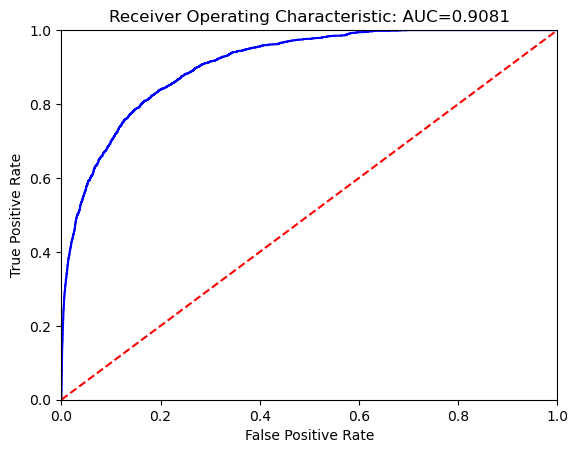

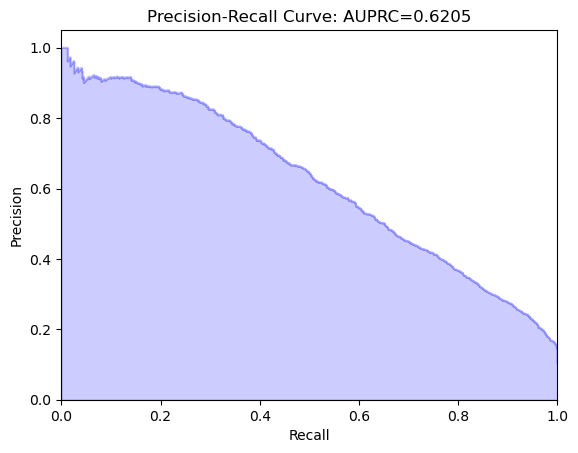

In [14]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [15]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task4.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.123264
1,1,0,0.003985
2,2,0,0.018018
3,3,0,0.646426
4,4,0,0.002664


GradientBoosting:
Training time: 31.682048797607422 seconds
AUC: 0.9149472105992342
AUPRC: 0.6454181880188032
Sensitivity: 0.8289538919186912
Specificity: 0.8285108138369969
Score thresold: 0.11032719056699318
2.5 97.5


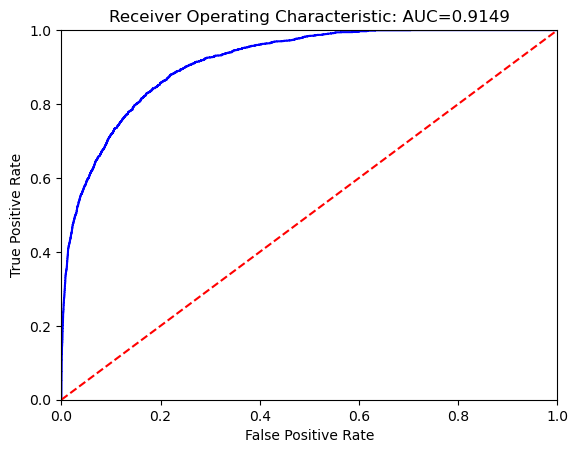

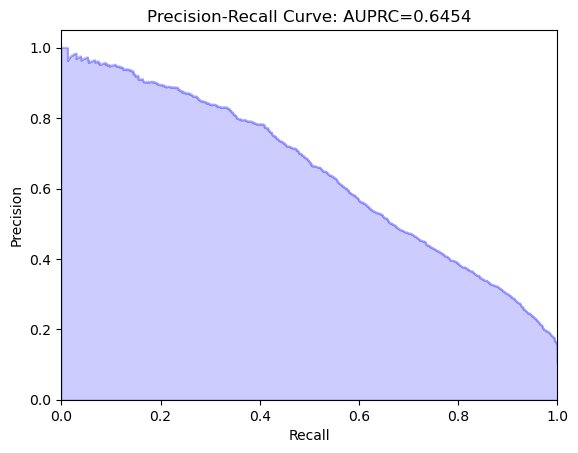

In [16]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [17]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task4.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.078643
1,1,0,0.055527
2,2,0,0.017421
3,3,0,0.017760
4,4,1,0.641420


In [18]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

2026-04-07 12:40:50.133240: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agd07
2026-04-07 12:40:50.133266: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agd07
2026-04-07 12:40:50.133348: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-04-07 12:40:50.133378: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


Epoch 1/20
760/760 [==============================] - 2s 984us/step - loss: 0.5171 - accuracy: 0.8950 - auc: 0.8168 - auprc: 0.3492 - tp: 3839.0000 - tn: 132105.0000 - precision: 0.5020 - recall: 0.2403
Epoch 2/20
760/760 [==============================] - 1s 888us/step - loss: 0.2378 - accuracy: 0.9073 - auc: 0.8701 - auprc: 0.4978 - tp: 4811.0000 - tn: 133000.0000 - precision: 0.6229 - recall: 0.3012
Epoch 3/20
760/760 [==============================] - 1s 868us/step - loss: 0.2334 - accuracy: 0.9090 - auc: 0.8758 - auprc: 0.5166 - tp: 5165.0000 - tn: 132895.0000 - precision: 0.6312 - recall: 0.3234
Epoch 4/20
760/760 [==============================] - 1s 918us/step - loss: 0.2345 - accuracy: 0.9093 - auc: 0.8752 - auprc: 0.5229 - tp: 5390.0000 - tn: 132726.0000 - precision: 0.6284 - recall: 0.3374
Epoch 5/20
760/760 [==============================] - 1s 858us/step - loss: 0.2250 - accuracy: 0.9128 - auc: 0.8842 - auprc: 0.5477 - tp: 5628.0000 - tn: 133021.0000 - precision: 0.6606 - 

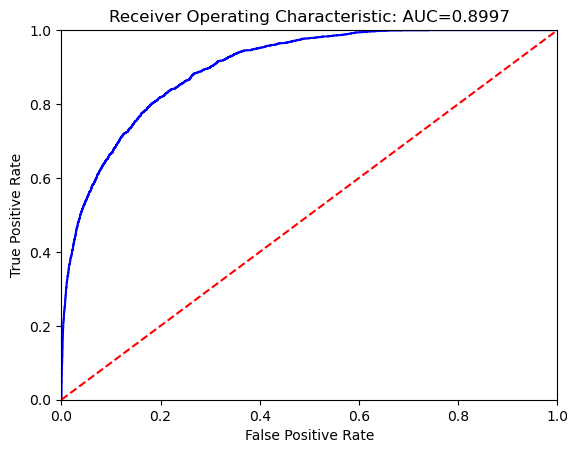

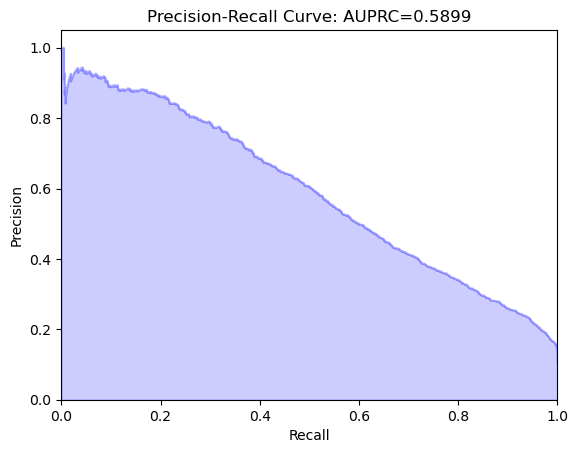

In [19]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('critical_disposition_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)